# CelebA-HQ Data Loading

This notebook loads the high-resolution CelebA-HQ dataset and formats it to match the codebase conventions:
- `coords`: `(N, 2)` — pixel grid coordinates in `[0, 1]²`
- `images`: `(B, N, 3)` — batch of B images with RGB channel values at each of the N grid points

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration

Set the resolution to downsample images to and the batch size.
The full 1024×1024 CelebA-HQ images give N = 1,048,576 points per image.
Resize to a smaller resolution for tractable experiments.

In [3]:
RESOLUTION = 128   # resize images to RESOLUTION x RESOLUTION
BATCH_SIZE = 8     # number of images per batch

## Build the Pixel Grid: `coords` of shape `(N, 2)`

Coordinates live in `[0, 1]²`, matching the `SquareSampler` convention used throughout the codebase.
The grid is row-major (x = column index, y = row index), both normalised to `[0, 1]`.

In [4]:
H = W = RESOLUTION
N = H * W

# linspace from 0.5/H to 1 - 0.5/H so each coordinate is the pixel centre
xs = torch.linspace(0.5 / W, 1.0 - 0.5 / W, W)   # (W,)
ys = torch.linspace(0.5 / H, 1.0 - 0.5 / H, H)   # (H,)

grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')   # each (H, W)
coords = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=-1)  # (N, 2)

print(f'coords shape : {coords.shape}')   # (N, 2)
print(f'coords range : [{coords.min():.4f}, {coords.max():.4f}]')

coords shape : torch.Size([16384, 2])
coords range : [0.0039, 0.9961]


## Load CelebA-HQ from Hugging Face

We use the `mattymchen/celeba-hq` dataset (30k images, 1024×1024) in streaming mode so we
don't have to download the full dataset up-front.

In [5]:
from datasets import load_dataset

ds = load_dataset("mattymchen/celeba-hq", split="train", streaming=True)
it = iter(ds)

sample = next(it)
print('Keys    :', list(sample.keys()))
print('Img type:', type(sample['image']))
print('Img size:', sample['image'].size)   # (W, H) in PIL

/home/hamid/miniconda3/envs/infidictionary/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Keys    : ['image', 'label']
Img type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Img size: (1024, 1024)


## Build an Image Batch: `images` of shape `(B, N, 3)`

Each PIL image is resized, converted to a float tensor in `[0, 1]`, then flattened
from `(3, H, W)` → `(N, 3)`.  Stacking over a batch gives `(B, N, 3)`.

In [6]:
to_tensor = transforms.Compose([
    transforms.Resize((H, W), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),    # -> (3, H, W) float32 in [0, 1]
])

def pil_to_signal(img: Image.Image) -> torch.Tensor:
    """Convert a PIL image to a (N, 3) signal tensor at the pixel-grid coords."""
    t = to_tensor(img)         # (3, H, W)
    t = t.permute(1, 2, 0)    # (H, W, 3)
    return t.reshape(N, 3)    # (N, 3)  — row-major, matches coords


# Rewind the iterator and collect BATCH_SIZE images
ds_fresh = load_dataset("mattymchen/celeba-hq", split="train", streaming=True)
raw_pils = [next(iter(ds_fresh))['image']] + [sample['image']]   # reuse the first sample

it2 = iter(ds_fresh)
raw_pils = [next(it2)['image'] for _ in range(BATCH_SIZE)]

signals = [pil_to_signal(img) for img in raw_pils]  # list of (N, 3)
images = torch.stack(signals, dim=0)                # (B, N, 3)

print(f'images shape : {images.shape}')   # (B, N, 3)
print(f'images dtype : {images.dtype}')
print(f'images range : [{images.min():.4f}, {images.max():.4f}]')

images shape : torch.Size([8, 16384, 3])
images dtype : torch.float32
images range : [0.0000, 1.0000]


## Move to Device

In [7]:
coords = coords.to(device)   # (N, 2)
images = images.to(device)   # (B, N, 3)

print(f'coords : {coords.shape}  on {coords.device}')
print(f'images : {images.shape}  on {images.device}')

coords : torch.Size([16384, 2])  on cuda:0
images : torch.Size([8, 16384, 3])  on cuda:0


## Visualisation

Reconstruct images from the `(B, N, 3)` signal tensor and display them.

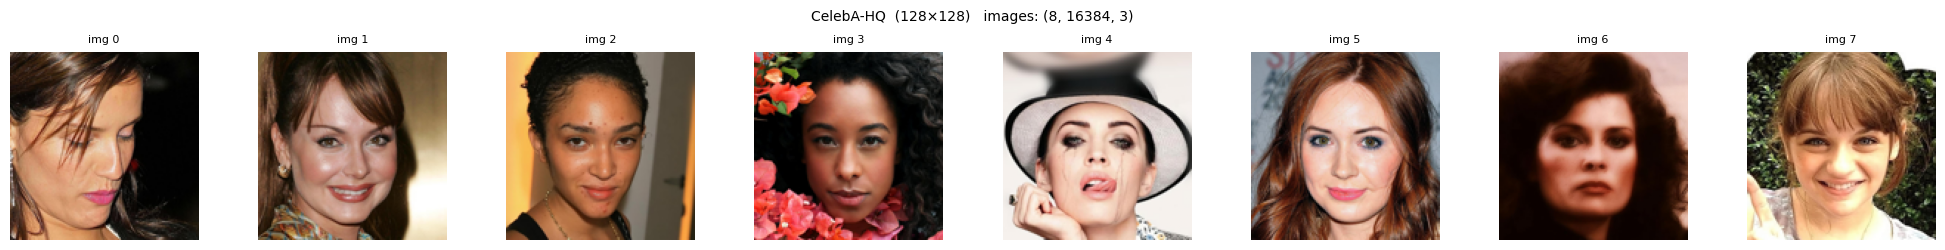

In [8]:
def signal_to_img(signal: torch.Tensor, h: int, w: int) -> np.ndarray:
    """Convert a (N, 3) signal tensor back to a (H, W, 3) uint8 numpy array."""
    img = signal.detach().cpu().reshape(h, w, 3).numpy()
    return np.clip(img, 0.0, 1.0)


n_show = min(BATCH_SIZE, 8)
fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 2.5))
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.imshow(signal_to_img(images[i], H, W))
    ax.set_title(f'img {i}', fontsize=8)
    ax.axis('off')

plt.suptitle(f'CelebA-HQ  ({H}×{W})   images: {tuple(images.shape)}', fontsize=10)
plt.tight_layout()
plt.show()

## Channel-wise Scatter Plot

Sanity-check that `coords` and `images` are aligned by scatter-plotting one channel over the 2-D grid.

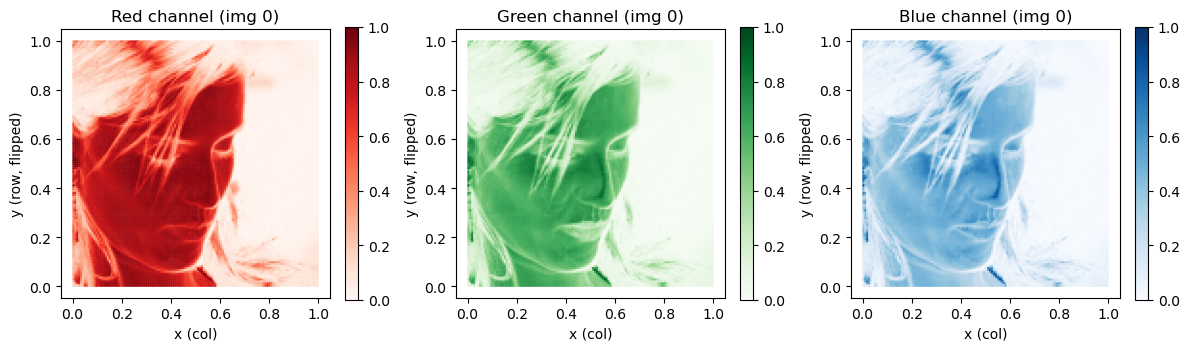

In [9]:
coords_np = coords.detach().cpu().numpy()   # (N, 2)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
channel_names = ['Red', 'Green', 'Blue']
cmaps = ['Reds', 'Greens', 'Blues']

img_idx = 0
for c, (ax, name, cmap) in enumerate(zip(axes, channel_names, cmaps)):
    vals = images[img_idx, :, c].detach().cpu().numpy()   # (N,)
    sc = ax.scatter(
        coords_np[:, 0], 1.0 - coords_np[:, 1],   # flip y so origin is top-left
        c=vals, cmap=cmap, s=1.0, vmin=0.0, vmax=1.0, rasterized=True,
    )
    plt.colorbar(sc, ax=ax, fraction=0.046)
    ax.set_title(f'{name} channel (img {img_idx})')
    ax.set_aspect('equal')
    ax.set_xlabel('x (col)');  ax.set_ylabel('y (row, flipped)')

plt.tight_layout()
plt.show()

## Irregular-Grid Pullback Experiment

Take two images, randomly drop a fraction of pixels to produce an irregular grid, then pull both signals back through a randomly-initialised `EulerianIsometry` (200 steps). We verify the isometry property by comparing inner products before and after the pullback, and we visualise the pulled-back images.

In [24]:
# ── 1. Pick two images and build an irregular (sparse) grid ──────────────────

DROP_FRACTION = 0.9   # fraction of pixels to discard
IMG_A, IMG_B = 0, 1  # indices into the batch

torch.manual_seed(42)
N_full = coords.shape[0]                                   # total pixels
N_keep = int(N_full * (1 - DROP_FRACTION))

# Random subset of pixel indices (no replacement)
keep_idx = torch.randperm(N_full, device=device)[:N_keep]  # (N_keep,)

# Sparse coords and signals  —  shapes (N_keep, 2) and (2, N_keep, 3)
sparse_coords  = coords[keep_idx]                          # (N_keep, 2)
sparse_logabsdet = torch.zeros(N_keep, device=device)     # uniform weights → log(1)=0

img_pair = images[[IMG_A, IMG_B]]                          # (2, N_full, 3)
sparse_signals = img_pair[:, keep_idx, :]                  # (2, N_keep, 3)

print(f"Full grid  : {N_full:,} pixels")
print(f"Sparse grid: {N_keep:,} pixels  ({DROP_FRACTION*100:.0f}% dropped)")
print(f"sparse_coords  : {tuple(sparse_coords.shape)}")
print(f"sparse_signals : {tuple(sparse_signals.shape)}")

Full grid  : 16,384 pixels
Sparse grid: 1,638 pixels  (90% dropped)
sparse_coords  : (1638, 2)
sparse_signals : (2, 1638, 3)


In [25]:
# ── 2. Build a randomly-initialised EulerianIsometry (200 steps) ─────────────

from functools import partial
from infidictionary.neural_isometries import EulerianIsometry
from infidictionary.utils import TimeEvolvingField, MLPNeuralField

# Mirror the architecture from conf/neural_isometry/eulerian.yaml
# but with channels_dim=3 for RGB
mlp_partial = partial(
    MLPNeuralField,
    hidden_dims={"a": 16, "b": 32, "c": 64, "d": 32},
    activation=torch.nn.ReLU,
)

def scalar_field_partial(coords_dim: int, output_dim: int) -> TimeEvolvingField:
    return TimeEvolvingField(base_field_partial=mlp_partial, coords_dim=coords_dim, output_dim=output_dim)

isometry = EulerianIsometry(
    coords_dim=2,
    channels_dim=3,
    scalar_field_partial=scalar_field_partial,
).to(device)

# Set the number of integration steps, then fix a deterministic tspan via eval()
isometry.shuffle_model_state(num_steps=200)
isometry.eval()   # sets tspan = linspace(0, 1, 200) and freezes BN/dropout if any

print(isometry)
print(f"\ntspan shape : {isometry.tspan.shape}")
print(f"tspan range : [{isometry.tspan.min():.4f}, {isometry.tspan.max():.4f}]")

EulerianIsometry(
  (function_field): TimeEvolvingField(
    (time_embedding): SinusoidalTimeEmbedding()
    (time_evolving_field): MLPNeuralField(
      (network): Sequential(
        (0): Linear(in_features=18, out_features=16, bias=True)
        (1): ReLU()
        (2): Linear(in_features=16, out_features=32, bias=True)
        (3): ReLU()
        (4): Linear(in_features=32, out_features=64, bias=True)
        (5): ReLU()
        (6): Linear(in_features=64, out_features=32, bias=True)
        (7): ReLU()
        (8): Linear(in_features=32, out_features=3, bias=True)
      )
    )
  )
)

tspan shape : torch.Size([200])
tspan range : [0.0000, 1.0000]


In [26]:
# ── 3. Pullback and inner-product comparison ──────────────────────────────────

from infidictionary.utils import pairwise_inner_product

with torch.no_grad():
    _, _, pulled_signals = isometry.pullback(
        tgt_coords=sparse_coords,
        tgt_logabsdet=sparse_logabsdet,
        tgt_field=sparse_signals,
        start_time=0.0,
        end_time=1.0,
    )

# Inner-product matrix  (2×2)  before and after pullback
ip_before = pairwise_inner_product(sparse_signals,  sparse_signals,  sparse_logabsdet)
ip_after  = pairwise_inner_product(pulled_signals,  pulled_signals,  sparse_logabsdet)

labels = [f"img {IMG_A}", f"img {IMG_B}"]
print("Inner-product matrix  BEFORE pullback:")
print(f"  {'':10s} {labels[0]:>12s} {labels[1]:>12s}")
for i, row_lbl in enumerate(labels):
    print(f"  {row_lbl:10s} {ip_before[i,0].item():12.6f} {ip_before[i,1].item():12.6f}")

print("\nInner-product matrix  AFTER pullback:")
print(f"  {'':10s} {labels[0]:>12s} {labels[1]:>12s}")
for i, row_lbl in enumerate(labels):
    print(f"  {row_lbl:10s} {ip_after[i,0].item():12.6f} {ip_after[i,1].item():12.6f}")

print("\nAbsolute difference (should be ~0 for a true isometry):")
print(f"  {(ip_before - ip_after).abs().max().item():.2e}  (max entry)")

Inner-product matrix  BEFORE pullback:
                    img 0        img 1
  img 0          0.519343     0.401854
  img 1          0.401854     0.706192

Inner-product matrix  AFTER pullback:
                    img 0        img 1
  img 0          0.519343     0.401854
  img 1          0.401854     0.706191

Absolute difference (should be ~0 for a true isometry):
  1.07e-06  (max entry)


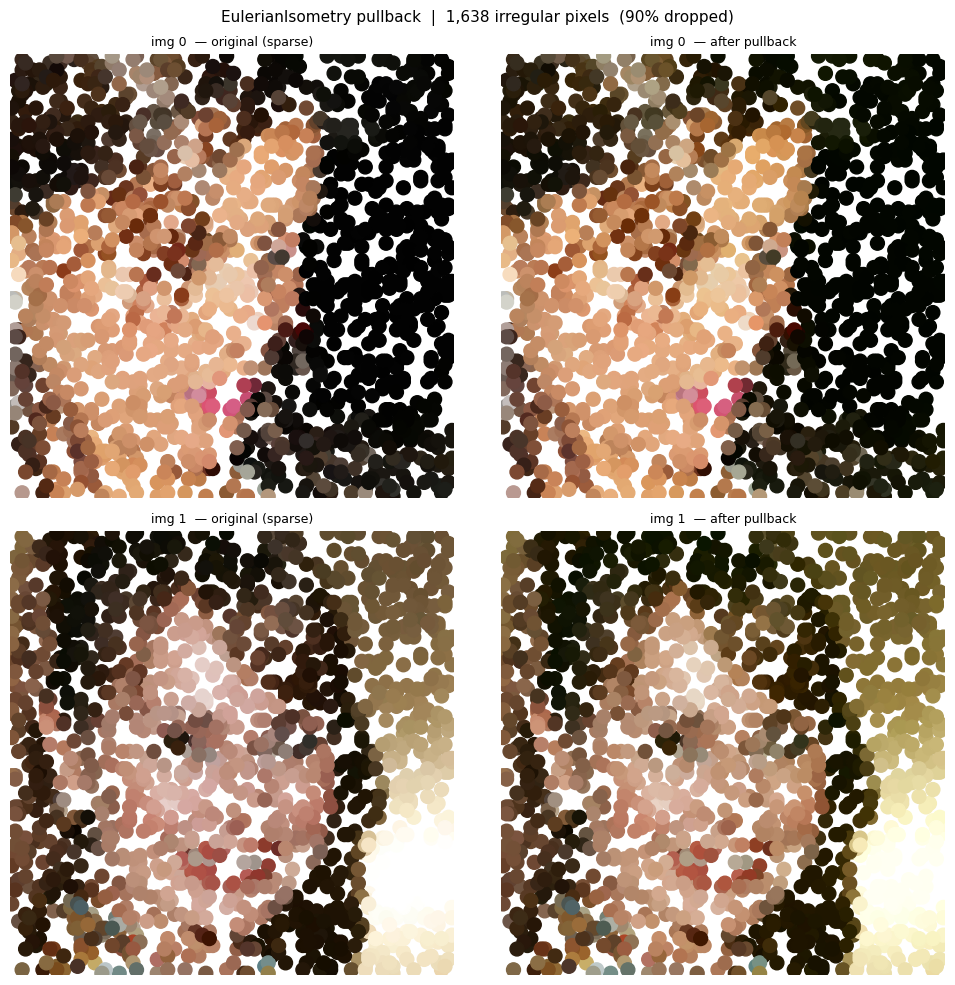

In [29]:
# ── 4. Visualisation: original vs pulled-back on the irregular grid ───────────

coords_np  = sparse_coords.detach().cpu().numpy()          # (N_keep, 2)
before_np  = sparse_signals.detach().cpu().numpy()         # (2, N_keep, 3)
after_np   = pulled_signals.detach().cpu().numpy()         # (2, N_keep, 3)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
titles = [
    (f"img {IMG_A}  — original (sparse)",  f"img {IMG_A}  — after pullback"),
    (f"img {IMG_B}  — original (sparse)",  f"img {IMG_B}  — after pullback"),
]

for row, (img_orig, img_pb, (t_orig, t_pb)) in enumerate(
    zip(before_np, after_np, titles)
):
    for col, (vals, title) in enumerate([(img_orig, t_orig), (img_pb, t_pb)]):
        ax = axes[row][col]
        # Clamp to [0, 1] and scatter-plot each point coloured by its RGB value
        rgb = np.clip(vals, 0.0, 1.0)                    # (N_keep, 3)
        ax.scatter(
            coords_np[:, 0],
            1.0 - coords_np[:, 1],                        # flip y: origin top-left
            c=rgb,
            s=100.0,
            rasterized=True,
        )
        ax.set_title(title, fontsize=9)
        ax.set_aspect("equal")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.axis("off")

plt.suptitle(
    f"EulerianIsometry pullback  |  {N_keep:,} irregular pixels  ({DROP_FRACTION*100:.0f}% dropped)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

In [18]:
sparse_coords.shape

torch.Size([8192, 2])